In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
print(torch.cuda.is_available())

True


In [12]:
def plt_hs(hs, min_fr=0.1, fig=None, ax=None, time_start=None, time_end=None):

    # time_points, num_neurons = hs.shape[0], hs.shape[1]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    
    time_pts, num_neurons = norm_hs.shape[0], norm_hs.shape[1]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_pts/10, num_neurons, 0]
              )
    
    # Plot a black dot at (max_time, neuron_index)
    if time_start is not None and time_end is not None:
        max_time_sorted = np.argmax(norm_hs, axis=0)
        # Plot those within the time interval
        time_mask = (max_time_sorted >= time_start) & (max_time_sorted <= time_end)
        y = np.arange(num_neurons)[time_mask]
        max_time_sorted = max_time_sorted[time_mask]
        ax.scatter(max_time_sorted/10, y, s=1, c='k')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))
    
    return norm_hs, fig, ax

In [18]:
num_neuron = 512

T = 100

# --- First event --- #
# time_start, time_end = int(T * 0.05), int(T * 0.45)
# time_start, time_end = int(T * 0.1), int(T * 0.4)
# time_start, time_end = int(T * 0.15), int(T * 0.35)
# time_start, time_end = int(T * 0.2), int(T * 0.3)
# time_start, time_end = int(T * 0.25), int(T * 0.3)

# --- Second event --- #
# time_start, time_end = int(T * 0.55), int(T * 0.95)
# time_start, time_end = int(T * 0.6), int(T * 0.9)
# time_start, time_end = int(T * 0.65), int(T * 0.85)
# time_start, time_end = int(T * 0.7), int(T * 0.8)
# time_start, time_end = int(T * 0.75), int(T * 0.80)

time_starts = [[int(T * 0.05), int(T * 0.25), int(T * 0.55)], 
               [int(T * 0.1),  int(T * 0.3),  int(T * 0.6)], 
               [int(T * 0.15), int(T * 0.35), int(T * 0.65)], 
               [int(T * 0.2),  int(T * 0.4),  int(T * 0.7)],
               [int(T * 0.25), int(T * 0.45), int(T * 0.75)]]
time_ends = [[int(T * 0.45), int(T * 0.75), int(T * 0.95)],
             [int(T * 0.4),  int(T * 0.7),  int(T * 0.9)],
             [int(T * 0.35), int(T * 0.65), int(T * 0.85)],
             [int(T * 0.3),  int(T * 0.6),  int(T * 0.8)],
             [int(T * 0.3),  int(T * 0.55), int(T * 0.8)]]
time_starts, time_ends = np.array(time_starts), np.array(time_ends)

In [25]:
idx = 1
for i in range(5):
    load_data_type = f'2WSMS_mask_vary{i+1}'
    data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
    hidden_states = data[f'hidden_states_{num_neuron}']
    avg_hs = np.mean(hidden_states, axis=0)
    print(avg_hs.shape)
    
    # Plot the average hidden states
    fig, ax = plt.subplots(figsize=(4, 3))
    norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax, 
                              time_start=time_starts[i, idx], time_end=time_ends[i, idx])
    plt.tight_layout()
    plt.xlabel('Time (s)')
    plt.close()

    # Get each neuron's max firing time
    max_time_pts = np.argmax(norm_hs, axis=0)  

    # Calculate the number of neurons with max firing time within the interval
    print('Interval length (s):', (time_ends[i, idx] - time_starts[i, idx])/10)
    
    # Select neurons with max firing time within the interval
    time_cell_idx = np.where((max_time_pts >= time_starts[i, idx]) & \
                             (max_time_pts <= time_ends[i, idx]))[0]
    num_time_cells = len(time_cell_idx)
    print('Num of time cells:', num_time_cells)
    time_cell_hs = norm_hs[time_starts[i, idx]:time_ends[i, idx], time_cell_idx]
    print('Time cell hs shape:', time_cell_hs.shape)
    print('')

(100, 512)
Interval length (s): 5.0
Num of time cells: 238
Time cell hs shape: (50, 238)

(100, 512)
Interval length (s): 4.0
Num of time cells: 175
Time cell hs shape: (40, 175)

(100, 512)
Interval length (s): 3.0
Num of time cells: 139
Time cell hs shape: (30, 139)

(100, 512)
Interval length (s): 2.0
Num of time cells: 73
Time cell hs shape: (20, 73)

(100, 512)
Interval length (s): 1.0
Num of time cells: 76
Time cell hs shape: (10, 76)



In [27]:
# Arena and coordinates
from rtgym.utils.data_processing import RatemapAggregator
from rtgym.utils.visualization import plot_ratemaps
import sys
sys.path.append('..')
from func import compute_occupancy, SIC_analysis, ratemap_to_angle_profile

for i in range(5):
    load_data_type = f'2WSMS_mask_vary{i+1}'
    data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
    hs = data[f'hidden_states_{num_neuron}']
    select_hs = hs[:, time_starts[i, idx]:time_ends[i, idx], :]
    print('select hs shape:', select_hs.shape)
    
    select_coords = data['test_traj']['coords'][:, time_starts[i, idx]:time_ends[i, idx], :]
    print('select coords shape:', select_coords.shape)

    # Find place cells
    arena = data['arena_map']
    occupancy = compute_occupancy(select_coords, bins=arena.shape)
    aggregator = RatemapAggregator(arena, device='cuda')
    aggregator.update(select_hs, select_coords)
    ratemap = aggregator.get_ratemap().cpu().numpy()

    ratemap_angles, angles, radius = ratemap_to_angle_profile(ratemap)
    occupancy_angles, _, _ = ratemap_to_angle_profile(occupancy[None, :, :])
    SIC, place_cells = SIC_analysis(ratemap_angles, occupancy_angles, threshold=8)
    print(f'Number of place cells: {np.sum(place_cells)} / {num_neuron}')
    print('')

select hs shape: (50, 50, 512)
select coords shape: (50, 50, 2)


Computing SIC for neurons: 100%|██████████| 512/512 [00:00<00:00, 125974.29it/s]

Number of place cells: 57 / 512

select hs shape: (50, 40, 512)
select coords shape: (50, 40, 2)


Computing SIC for neurons: 100%|██████████| 512/512 [00:00<00:00, 129483.49it/s]


Number of place cells: 75 / 512

select hs shape: (50, 30, 512)
select coords shape: (50, 30, 2)


...

select hs shape: (50, 20, 512)
select coords shape: (50, 20, 2)


Computing SIC for neurons: 100%|██████████| 512/512 [00:00<00:00, 173983.93it/s]


Number of place cells: 16 / 512

select hs shape: (50, 10, 512)
select coords shape: (50, 10, 2)


Computing SIC for neurons: 100%|██████████| 512/512 [00:00<00:00, 196944.58it/s]

Number of place cells: 13 / 512



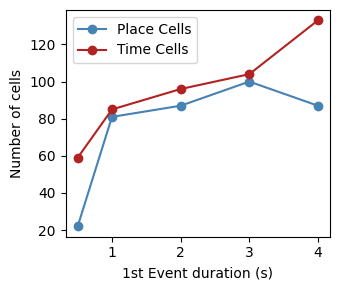

In [ ]:
num_time_cells1 = [133, 104, 96, 85, 59]
num_place_cells1 = [87, 100, 87, 81, 22]
intervals = [4.0, 3.0, 2.0, 1.0, 0.5]

# Plot proportion of place cells vs time cells
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.plot(intervals, num_place_cells1, marker='o', color='steelblue', label='Place Cells')
ax.plot(intervals, num_time_cells1, marker='o', color='firebrick', label='Time Cells')
ax.set_xlabel('1st Event duration (s)')
ax.set_ylabel('Number of cells')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_time_place_1st_event.png', dpi=500, transparent=True)
plt.show()

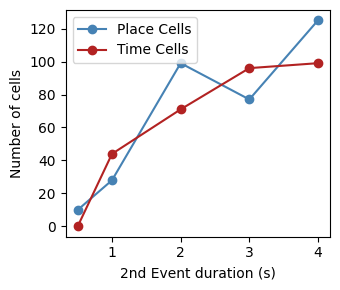

In [ ]:
num_time_cells2 = [99,96,71,44,0]
num_place_cells2 = [125,77,99,28,10]
intervals = [4.0, 3.0, 2.0, 1.0, 0.5]

# Plot proportion of place cells vs time cells
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.plot(intervals, num_place_cells2, marker='o', color='steelblue', label='Place Cells')
ax.plot(intervals, num_time_cells2, marker='o', color='firebrick', label='Time Cells')
ax.set_xlabel('2nd Event duration (s)')
ax.set_ylabel('Number of cells')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_time_place_2nd_event.png', dpi=500, transparent=True)
plt.show()

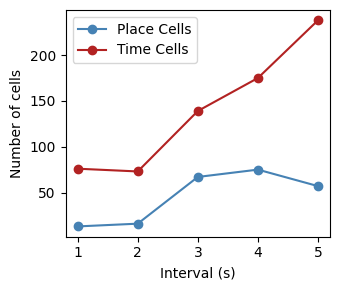

In [ ]:
num_time_cells = [238,175,139,73,76]
num_place_cells = [57,75,67,16,13]
intervals = [5.0, 4.0, 3.0, 2.0, 1.0]

# Plot proportion of place cells vs time cells
fig, ax = plt.subplots(figsize=(3.5, 3))
ax.plot(intervals, num_place_cells, marker='o', color='steelblue', label='Place Cells')
ax.plot(intervals, num_time_cells, marker='o', color='firebrick', label='Time Cells')
ax.set_xlabel('Interval (s)')
ax.set_ylabel('Number of cells')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_time_place_interval.png', dpi=500, transparent=True)
plt.show()

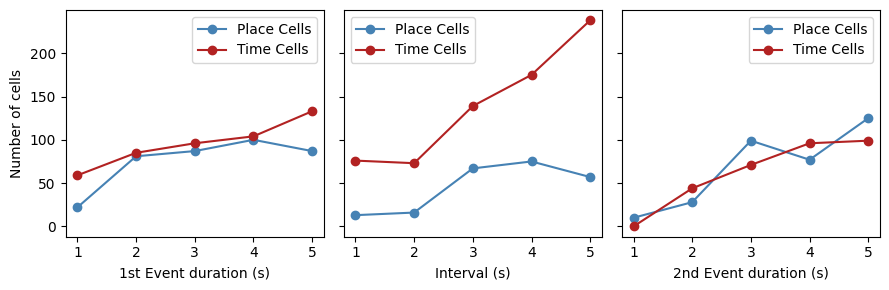

In [ ]:
# Plot three figures together
fig, axs = plt.subplots(1, 3, figsize=(9, 3), sharey=True)
# First event
axs[0].plot(intervals, num_place_cells1, marker='o', color='steelblue', label='Place Cells')
axs[0].plot(intervals, num_time_cells1, marker='o', color='firebrick', label='Time Cells')
axs[1].plot(intervals, num_place_cells, marker='o', color='steelblue', label='Place Cells')
axs[1].plot(intervals, num_time_cells, marker='o', color='firebrick', label='Time Cells')
axs[2].plot(intervals, num_place_cells2, marker='o', color='steelblue', label='Place Cells')
axs[2].plot(intervals, num_time_cells2, marker='o', color='firebrick', label='Time Cells')
axs[0].set_xlabel('1st Event duration (s)')
axs[0].set_ylabel('Number of cells')
axs[1].set_xlabel('Interval (s)')
axs[2].set_xlabel('2nd Event duration (s)')
axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.tight_layout()
plt.savefig('fig3_time_place_all.png', dpi=500, transparent=True)
plt.show()